In [1]:
# Importing and NLTK downloads
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# NLTK setup
import nltk
nltk.download('twitter_samples')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import twitter_samples
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package twitter_samples to
[nltk_data]     C:\Users\gurur\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\twitter_samples.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gurur\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gurur\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gurur\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\gurur\AppData\Roaming\nltk_data...


In [2]:
#Loading data
DATA_CSV = "data/tweets.csv" 

if os.path.exists(DATA_CSV):
    df = pd.read_csv(DATA_CSV)
    # try to standardize column names
    if 'text' not in df.columns:
        if 'tweet' in df.columns:
            df.rename(columns={'tweet':'text'}, inplace=True)
    if 'label' not in df.columns and 'sentiment' in df.columns:
        df.rename(columns={'sentiment':'label'}, inplace=True)
    print("Loaded user CSV:", DATA_CSV)
else:
    # Use NLTK built-in movie/twitter samples
    pos = twitter_samples.strings('positive_tweets.json')
    neg = twitter_samples.strings('negative_tweets.json')
    df_pos = pd.DataFrame({'text': pos, 'label': 1})
    df_neg = pd.DataFrame({'text': neg, 'label': 0})
    df = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)
    print("Loaded NLTK twitter_samples (pos/neg).")

print("Shape:", df.shape)
df.head()

Loaded NLTK twitter_samples (pos/neg).
Shape: (10000, 2)


,text,label
0,"I love you, how but you? @Taecyeon2pm8 did you...",0
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_...,1
2,"Your love, O Lord, is better than life. :) &lt...",1
3,@yasminyasir96 yeah but it will be better if w...,1
4,Ok good night I wish troye wasn't ugly and I m...,1


label
0    5000
1    5000
Name: count, dtype: int64


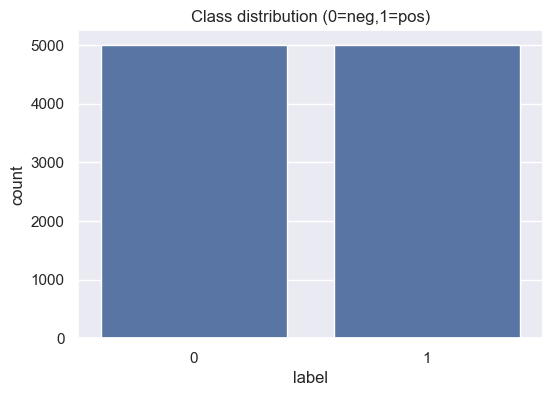

,text,label
9953,Jahat :(,0
3850,@SyuhxdxTengku most welcome :),1
4962,@uptommosass it's 9:25 am here :) I live in Sc...,1
3886,@daiIysolos zayn malik please :((,0
5437,not even sleepy :(,0
8517,@TimmiTRetro @S0LV0 @sonicretro sorry solvo ;-...,0


In [3]:
# quick EDA (class balance, sample)
print(df['label'].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Class distribution (0=neg,1=pos)")
plt.show()

# show samples
df.sample(6, random_state=1)

In [9]:
# Step 4: Preprocessing functions
import re
import nltk
import os
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Set the NLTK data path
nltk_data_path = r'C:\Users\gurur\AppData\Roaming\nltk_data'
nltk.data.path.append(nltk_data_path)

# Create directory if it doesn't exist
os.makedirs(nltk_data_path, exist_ok=True)

# Download required NLTK data
try:
    nltk.download('punkt', download_dir=nltk_data_path, quiet=True)
    nltk.download('stopwords', download_dir=nltk_data_path, quiet=True)
    nltk.download('wordnet', download_dir=nltk_data_path, quiet=True)
    nltk.download('omw-1.4', download_dir=nltk_data_path, quiet=True)  # Added for better lemmatization
except Exception as e:
    print(f"Download error: {e}")
    # Fallback to default download location
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    """
    Clean and preprocess tweet text
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    
    text = text.lower()  # lowercase
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)     # remove mentions
    text = re.sub(r'#', '', text)        # remove hashtag symbol only
    text = re.sub(r'[^a-z\s]', ' ', text)  # keep letters only
    text = re.sub(r'\s+', ' ', text)     # remove extra whitespace
    
    try:
        tokens = nltk.word_tokenize(text)
        tokens = [lemmatizer.lemmatize(tok) for tok in tokens 
                 if tok not in stop_words and len(tok) > 1]
        return " ".join(tokens)
    except Exception as e:
        print(f"Tokenization error: {e}")
        return text.strip()

# Quick test
test_text = "I love this! #awesome http://test.com @user"
print(f"Original: {test_text}")
print(f"Cleaned: {clean_tweet(test_text)}")

Original: I love this! #awesome http://test.com @user
Tokenization error: 
**********************************************************************
  Resource punkt_tab not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load tokenizers/punkt_tab/english/

  Searched in:
    - 'C:\\Users\\gurur/nltk_data'
    - 'C:\\Users\\gurur\\AppData\\Local\\Programs\\Python\\Python311\\nltk_data'
    - 'C:\\Users\\gurur\\AppData\\Local\\Programs\\Python\\Python311\\share\\nltk_data'
    - 'C:\\Users\\gurur\\AppData\\Local\\Programs\\Python\\Python311\\lib\\nltk_data'
    - 'C:\\Users\\gurur\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
    - 'C:\\Users\\gurur\\AppData\\Roaming\\nltk_data'
    - 'C:\\Users\\gurur\\AppData\\Roaming\\nltk_data'
    - 'C:\\Users\\gurur\\AppData\\Roaming\\nltk_data'
************

In [11]:
# Preprocessing functions - UPDATED VERSION
import re
import nltk
import os
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import ssl

# Disable SSL verification to avoid certificate issues during download
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Set the NLTK data path
nltk_data_path = r'C:\Users\gurur\AppData\Roaming\nltk_data'
nltk.data.path.append(nltk_data_path)

# Create directory if it doesn't exist
os.makedirs(nltk_data_path, exist_ok=True)

# Download required NLTK data with updated punkt_tab
print("Downloading NLTK data...")
try:
    nltk.download('punkt_tab', download_dir=nltk_data_path, quiet=False)
    nltk.download('stopwords', download_dir=nltk_data_path, quiet=False)
    nltk.download('wordnet', download_dir=nltk_data_path, quiet=False)
    nltk.download('omw-1.4', download_dir=nltk_data_path, quiet=False)
    print("All NLTK downloads completed successfully!")
except Exception as e:
    print(f"Download error: {e}")
    print("Trying alternative download method...")
    # Fallback to default download location
    nltk.download('punkt_tab', quiet=False)
    nltk.download('stopwords', quiet=False)
    nltk.download('wordnet', quiet=False)
    nltk.download('omw-1.4', quiet=False)

# Alternative approach if punkt_tab still causes issues
# Use the standard punkt tokenizer with a fallback
try:
    # Test if punkt_tab works
    nltk.data.find('tokenizers/punkt_tab')
    print("Using punkt_tab tokenizer")
except LookupError:
    print("punkt_tab not found, downloading standard punkt...")
    try:
        nltk.download('punkt', download_dir=nltk_data_path, quiet=False)
        print("Using standard punkt tokenizer")
    except:
        print("Falling back to basic tokenization")

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\gurur\AppData\Roaming\nltk_data...


All NLTK downloads completed successfully!
Using punkt_tab tokenizer


[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gurur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gurur\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\gurur\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [12]:
# apply cleaning (store original text too)
df['text_clean'] = df['text'].astype(str).apply(clean_tweet)
df[['text','text_clean']].head(6)

,text,text_clean
0,"I love you, how but you? @Taecyeon2pm8 did you...",love feel emm think
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_...,thanks guy
2,"Your love, O Lord, is better than life. :) &lt...",love lord better life lt
3,@yasminyasir96 yeah but it will be better if w...,yeah better use official account like
4,Ok good night I wish troye wasn't ugly and I m...,ok good night wish troye ugly met today ok tod...
5,"@scottybev I'm not surprised, that sounds hell...",surprised sound hellish would thing


In [13]:
# test/split
X = df['text_clean']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (8000,) Test: (2000,)


In [14]:
# Validation
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF matrix shapes:", X_train_tfidf.shape, X_test_tfidf.shape)

TF-IDF matrix shapes: (8000, 5000) (2000, 5000)


In [15]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
print("LogReg Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

LogReg Accuracy: 0.752
              precision    recall  f1-score   support

           0       0.74      0.78      0.76      1000
           1       0.77      0.72      0.74      1000

    accuracy                           0.75      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.75      0.75      0.75      2000



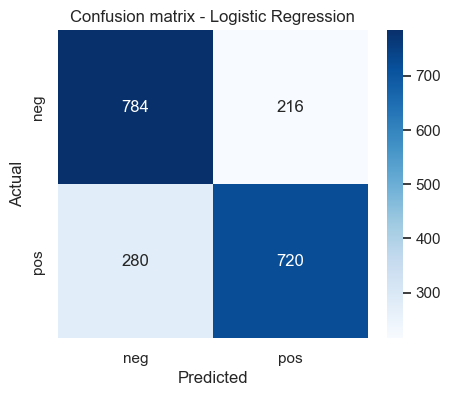

In [16]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['neg','pos'], yticklabels=['neg','pos'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion matrix - Logistic Regression')
plt.show()

In [17]:
# Try Multinomial Naive Bayes and compare
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)
print("NB Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

NB Accuracy: 0.7465
              precision    recall  f1-score   support

           0       0.72      0.81      0.76      1000
           1       0.78      0.69      0.73      1000

    accuracy                           0.75      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.75      0.75      0.75      2000



In [18]:
# Save model + vectorizer + sample predictions
os.makedirs("output", exist_ok=True)
joblib.dump(lr, "output/logreg_model.joblib")
joblib.dump(tfidf, "output/tfidf_vectorizer.joblib")
print("Saved logreg_model.joblib & tfidf_vectorizer.joblib in output/")

sample_results = pd.DataFrame({
    'text_original': X_test.values,
    'text_clean': X_test,
    'true': y_test.values,
    'pred_logreg': y_pred_lr,
    'pred_nb': y_pred_nb
})
sample_results.reset_index(drop=True).head(20).to_csv("output/sample_predictions.csv", index=False)
print("Saved sample_predictions.csv")


Saved logreg_model.joblib & tfidf_vectorizer.joblib in output/
Saved sample_predictions.csv


In [ ]:
# Quick function to predict new tweet
def predict_text(raw_text):
    cleaned = clean_tweet(raw_text)
    vec = tfidf.transform([cleaned])
    prob = lr.predict_proba(vec)[0]
    pred = lr.predict(vec)[0]
    return {"text":raw_text, "clean":cleaned, "pred":int(pred), "prob_neg":float(prob[0]), "prob_pos":float(prob[1])}

# Example:
print(predict_text("I really enjoyed the new movie, it was awesome!"))
print(predict_text("This is the worst service ever. Totally disappointed."))
